
========== TF-IDF MODEL ==========
F1 Score: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         8
           1       1.00      1.00      1.00         7
           2       1.00      1.00      1.00         8
           3       1.00      1.00      1.00         7

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



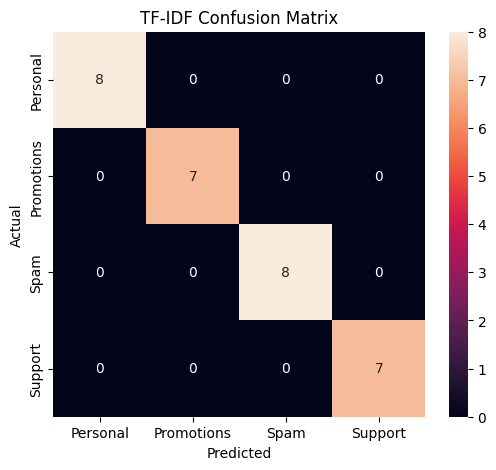

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



========== BERT MODEL ==========
F1 Score: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         8
           1       1.00      1.00      1.00         7
           2       1.00      1.00      1.00         8
           3       1.00      1.00      1.00         7

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



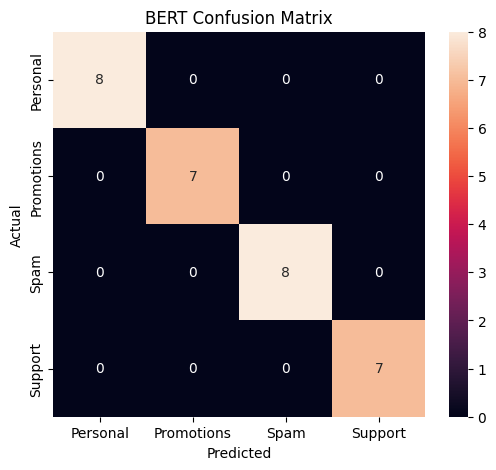

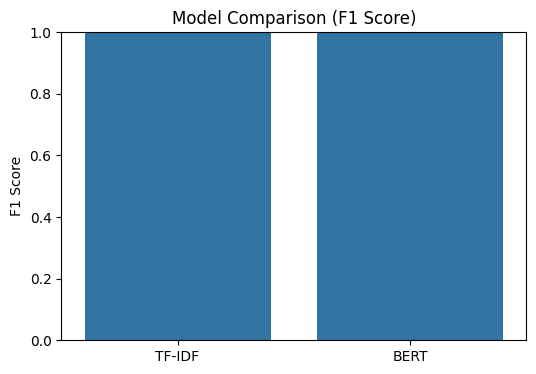


Predicted Category (BERT): Promotions


In [2]:

!pip -q install transformers seaborn

import pandas as pd
import numpy as np
import re
import torch
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, f1_score
from sklearn.preprocessing import LabelEncoder

from transformers import AutoTokenizer, AutoModel

emails = [

"Win money now", "Claim your free prize", "Lottery winner announcement",
"Congratulations you won cash", "Free vacation offer",

"Big sale this weekend", "50 percent discount today",
"Exclusive shopping deal", "Limited time offer",
"Flash sale starts now",

"I need help with my account", "Reset my password please",
"My order is not delivered", "Having login issues",
"Please resolve my complaint",

"Are we meeting tomorrow?", "Let's have dinner tonight",
"Call me when free", "Happy birthday dear",
"See you soon friend"
] * 5

categories = (
["Spam"]*5 +
["Promotions"]*5 +
["Support"]*5 +
["Personal"]*5
) * 5

df = pd.DataFrame({"email": emails, "category": categories})

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    return text

df["clean_email"] = df["email"].apply(clean_text)

label_encoder = LabelEncoder()
df["label"] = label_encoder.fit_transform(df["category"])

X_train, X_test, y_train, y_test = train_test_split(
    df["clean_email"],
    df["label"],
    test_size=0.3,
    stratify=df["label"],
    random_state=42
)

tfidf = TfidfVectorizer()
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

tfidf_model = LogisticRegression(max_iter=1000)
tfidf_model.fit(X_train_tfidf, y_train)

y_pred_tfidf = tfidf_model.predict(X_test_tfidf)
f1_tfidf = f1_score(y_test, y_pred_tfidf, average='weighted')

print("\n========== TF-IDF MODEL ==========")
print("F1 Score:", f1_tfidf)
print(classification_report(y_test, y_pred_tfidf))

cm_tfidf = confusion_matrix(y_test, y_pred_tfidf)
plt.figure(figsize=(6,5))
sns.heatmap(cm_tfidf, annot=True, fmt='d',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title("TF-IDF Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")
bert_model = AutoModel.from_pretrained("distilbert-base-uncased")

def get_bert_embeddings(text_list):
    embeddings = []
    for text in text_list:
        inputs = tokenizer(text, return_tensors="pt",
                           truncation=True, padding=True, max_length=128)
        outputs = bert_model(**inputs)
        cls_embedding = outputs.last_hidden_state[:, 0, :].detach().numpy()
        embeddings.append(cls_embedding.flatten())
    return np.array(embeddings)

X_train_bert = get_bert_embeddings(X_train.tolist())
X_test_bert = get_bert_embeddings(X_test.tolist())

bert_classifier = LogisticRegression(max_iter=1000)
bert_classifier.fit(X_train_bert, y_train)

y_pred_bert = bert_classifier.predict(X_test_bert)
f1_bert = f1_score(y_test, y_pred_bert, average='weighted')

print("\n========== BERT MODEL ==========")
print("F1 Score:", f1_bert)
print(classification_report(y_test, y_pred_bert))

cm_bert = confusion_matrix(y_test, y_pred_bert)
plt.figure(figsize=(6,5))
sns.heatmap(cm_bert, annot=True, fmt='d',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title("BERT Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

models = ["TF-IDF", "BERT"]
scores = [f1_tfidf, f1_bert]

plt.figure(figsize=(6,4))
sns.barplot(x=models, y=scores)
plt.title("Model Comparison (F1 Score)")
plt.ylabel("F1 Score")
plt.ylim(0,1)
plt.show()

def predict_email(email_text, model_type="bert"):
    email_text = clean_text(email_text)

    if model_type == "tfidf":
        vector = tfidf.transform([email_text])
        prediction = tfidf_model.predict(vector)
    else:
        vector = get_bert_embeddings([email_text])
        prediction = bert_classifier.predict(vector)

    return label_encoder.inverse_transform(prediction)[0]

test_email = "Get 50 percent discount now!"
print("\nPredicted Category (BERT):",
      predict_email(test_email, model_type="bert"))